<h3>USING SAME ARCHITECTURE AS "classifierModel.ipynb" -> <b>ResNet</b></h3>

<p><b><u>TRAIN/TEST CLASSIFIER FOR IMAGES IN THE FOLDER:</u></b></p>
<ul>
    <li>- <b>TRAIN:</b> D:/augmented_data_<b>consistent</b>_backgrounds/images/train/...</li>
    <li>- <b>TEST:</b> D:/augmented_data_<b>consistent</b>_backgrounds/images/val/...</li>
</ul>

<p><b><u>ONLY WORKING ON TRAINING THESE INSTRUMENTS FOR NOW [MEANS TOTAL INSTRUMENTS IN THE PATH ABOVE]</u></b></p>
<ul>
    <li><b>TOTALLY DIFFERENT INSTRUMENTS</b></li>
        <li style="list-style-type: none;"><pre>- [1820] Tissue Forceps, Adson Straight 1x2 Teeth Mirror Finish 4.75in</pre></li>
        <li style="list-style-type: none;"><pre>- [1820] Needle Holder, Ryder Straight Carb-bite Serrated Jaws 8in</pre></li>
        <li style="list-style-type: none;"><pre>- [1820] Sponge Holding Forceps, Foerster Straight Serrated 9.5in</pre></li>
</ul>

In [77]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parent)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_loaders.augmentedMasterTestDataLoader import loadAndSaveData_a

In [78]:
# load and save data
loadAndSaveData_a(root_dir="D:\\augmented_data_random_backgrounds\\images\\train", csvSave="..\\data\\augmenteddata_randombackground.csv")

# Load the data into a pandas dataframe [SUCCESSFULLY LOADS ALL IMAGES AND METADATA]
df = pd.DataFrame(pd.read_csv("..\\data\\augmenteddata_randombackground.csv"))

df["instrument"] = df["instrument"].replace(
    "Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in right side up",
    "Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in"
)

df

,image_path,instrument,state,image_id,background_aug
0,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,0.0
1,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,1.0
2,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,2.0
3,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,3.0
4,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,4.0
...,...,...,...,...,...
3620,D:\augmented_data_random_backgrounds\images\tr...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,45,7.0
3621,D:\augmented_data_random_backgrounds\images\tr...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,45,8.0
3622,D:\augmented_data_random_backgrounds\images\tr...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,45,9.0
3623,D:\augmented_data_random_backgrounds\images\tr...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,45,10.0


In [79]:
instruments = [
    "Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in",
    "Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in", 
    "Sponge Holding Forceps Foerster Straight Serrated 9.5in"
]

state = ["closed"]

# Filter dataset
df_filtered = df[
    (df["instrument"].isin(instruments)) &
    (df["state"].isin(state))
]

# Create label map
label_map = {name: i for i, name in enumerate(instruments)}

# Assign labels
df_filtered["label"] = df_filtered["instrument"].map(label_map)

df_filtered

,image_path,instrument,state,image_id,background_aug,label
0,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,0.0,1
1,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,1.0,1
2,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,2.0,1
3,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,3.0,1
4,D:\augmented_data_random_backgrounds\images\tr...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,4.0,1
...,...,...,...,...,...,...
2101,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,15.0,2
2102,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,16.0,2
2103,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,17.0,2
2104,D:\augmented_data_random_backgrounds\images\tr...,Sponge Holding Forceps Foerster Straight Serra...,closed,25,18.0,2


## TRAIN/VALIDATION SPLIT with TRAINING DATASET

In [80]:
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader
from data_loaders.InstrumentDataset import InstrumentDataset

In [81]:
df_filtered["group"] = (
    df_filtered["instrument"] + "_" +
    df_filtered["state"] + "_" +
    df_filtered["image_id"].astype(str)
)

# Group-based split
gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(df_filtered, groups=df_filtered["group"]))

trainDF = df_filtered.iloc[train_idx]
testDF = df_filtered.iloc[test_idx]

In [82]:
# get the instrument data by using the InstrumentDataset class
trainDataset = InstrumentDataset(trainDF)
testDataset = InstrumentDataset(testDF)

# load the data
trainLoader = DataLoader(trainDataset, batch_size=32, shuffle=True, num_workers=4)
testLoader = DataLoader(testDataset, batch_size=32, shuffle=False, num_workers=4)

### ResNet 18

In [83]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# create the resnet model
model = resnet18(weights=ResNet18_Weights.DEFAULT)

# replace final layer
model.fc = nn.Linear(model.fc.in_features, 3)

# initialize model in device (preferably GPU)
model = model.to(device)

# confirmation
print("MODEL INITIALIZED!")

Using: cuda
MODEL INITIALIZED!


In [84]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [85]:
loss_file = "models/AR_best_loss.txt"

# Load previous best loss if it exists
if os.path.exists(loss_file):
    with open(loss_file, "r") as f:
        bestValLoss = float(f.read())
    print(f"Loaded previous best loss: {bestValLoss}")
else:
    bestValLoss = float('inf')
    print("No previous loss found, starting fresh.")

# TRAINING LOOP
for epoch in range(50):
    model.train()
    total_loss = 0

    for imgs, labels in trainLoader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    if total_loss < bestValLoss:
        bestValLoss = total_loss

        # save model
        torch.save(model.state_dict(), 'models\\augmentedRandomBG_weights.pth')

        # save loss
        with open(loss_file, "w") as f:
            f.write(str(bestValLoss))

        print("\t=> Best Model + Loss Saved!")

No previous loss found, starting fresh.
Epoch 1, Loss: 12.7523
	=> Best Model + Loss Saved!
Epoch 2, Loss: 2.5004
	=> Best Model + Loss Saved!
Epoch 3, Loss: 2.6514
Epoch 4, Loss: 1.8428
	=> Best Model + Loss Saved!
Epoch 5, Loss: 1.1389
	=> Best Model + Loss Saved!
Epoch 6, Loss: 0.4362
	=> Best Model + Loss Saved!
Epoch 7, Loss: 0.1770
	=> Best Model + Loss Saved!
Epoch 8, Loss: 0.1356
	=> Best Model + Loss Saved!
Epoch 9, Loss: 0.0754
	=> Best Model + Loss Saved!
Epoch 10, Loss: 0.0947
Epoch 11, Loss: 0.0522
	=> Best Model + Loss Saved!
Epoch 12, Loss: 0.0531
Epoch 13, Loss: 0.0402
	=> Best Model + Loss Saved!
Epoch 14, Loss: 0.0606
Epoch 15, Loss: 0.0501
Epoch 16, Loss: 0.0400
	=> Best Model + Loss Saved!
Epoch 17, Loss: 0.0363
	=> Best Model + Loss Saved!
Epoch 18, Loss: 0.0200
	=> Best Model + Loss Saved!
Epoch 19, Loss: 0.0205
Epoch 20, Loss: 0.0229
Epoch 21, Loss: 0.0202
Epoch 22, Loss: 0.0178
	=> Best Model + Loss Saved!
Epoch 23, Loss: 0.0265
Epoch 24, Loss: 0.0221
Epoch 25, 

In [86]:
# load best weights
model.load_state_dict(torch.load('models\\augmentedRandomBG_weights.pth', weights_only=True))

# TESTING LOOP
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in testLoader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Validation Accuracy: 88.96%


## TEST WITH AUGMENTED TESTING DATA

In [87]:
from torchvision import transforms
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [88]:
# LOAD VALIDATION (VAL) DATA
loadAndSaveData_a(
    root_dir="D:\\augmented_data_random_backgrounds\\images\\val",
    csvSave="..\\data\\augmenteddata_randombackground_VAL.csv"
)

df_val = pd.DataFrame(pd.read_csv("..\\data\\augmenteddata_randombackground_VAL.csv"))

df_val["instrument"] = df_val["instrument"].replace(
    "Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in right side up",
    "Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in"
)

df_val

,image_path,instrument,state,image_id,background_aug
0,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,NaN
1,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,6.0
2,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,10.0
3,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,17.0
4,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,19.0
...,...,...,...,...,...
768,D:\augmented_data_random_backgrounds\images\va...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,50,20.0
769,D:\augmented_data_random_backgrounds\images\va...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,50,21.0
770,D:\augmented_data_random_backgrounds\images\va...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,50,22.0
771,D:\augmented_data_random_backgrounds\images\va...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,50,23.0


In [89]:
print(df_val["instrument"].value_counts())

instrument
Sponge Holding Forceps Foerster Straight Serrated 9.5in          218
Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in    217
Needle Holder Ryder Straight Carb-bite Serrated Jaws 8in         195
Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in     143
Name: count, dtype: int64


In [90]:

pd.crosstab(
    df_val["instrument"],
    df_val["state"]
)

state,closed,open
instrument,,
Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in,103,114
Needle Holder Ryder Straight Carb-bite Serrated Jaws 8in,108,87
Sponge Holding Forceps Foerster Straight Serrated 9.5in,107,111
Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in,0,143


In [91]:
instruments_state = {
    "Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in" : "closed", 
    "Sponge Holding Forceps Foerster Straight Serrated 9.5in" : "closed",
    "Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in" : "open"
}

df_val_filtered = df_val[
    df_val["state"] == df_val["instrument"].map(instruments_state)
].copy()

# use SAME label_map
df_val_filtered["label"] = df_val_filtered["instrument"].map(label_map)

df_val_filtered

,image_path,instrument,state,image_id,background_aug,label
0,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,NaN,1
1,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,6.0,1
2,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,10.0,1
3,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,17.0,1
4,D:\augmented_data_random_backgrounds\images\va...,Needle Holder Mayo-Hegar Straight Carb-bite Se...,closed,1,19.0,1
...,...,...,...,...,...,...
768,D:\augmented_data_random_backgrounds\images\va...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,50,20.0,0
769,D:\augmented_data_random_backgrounds\images\va...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,50,21.0,0
770,D:\augmented_data_random_backgrounds\images\va...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,50,22.0,0
771,D:\augmented_data_random_backgrounds\images\va...,Tissue Forceps Adson Straight 1x2 Teeth Mirror...,open,50,23.0,0


In [92]:
print(df_val_filtered["instrument"].value_counts())

instrument
Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in     143
Sponge Holding Forceps Foerster Straight Serrated 9.5in          107
Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in    103
Name: count, dtype: int64


In [93]:
pd.crosstab(
    df_val_filtered["instrument"],
    df_val_filtered["state"]
)

state,closed,open
instrument,,
Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in,103,0
Sponge Holding Forceps Foerster Straight Serrated 9.5in,107,0
Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in,0,143


In [94]:
# create dataset and loader (non-occluded)
valDataset = InstrumentDataset(df_val_filtered, apply_occlusion=False)
valLoader = DataLoader(valDataset, batch_size=32, shuffle=False)

# create dataset and loader (occluded)
valDatasetOccluded = InstrumentDataset(df_val_filtered, apply_occlusion=True)
valLoaderOccluded = DataLoader(valDatasetOccluded, batch_size=32, shuffle=False)

# load model
model.load_state_dict(torch.load('models\\augmentedRandomBG_weights.pth', weights_only=True))

<All keys matched successfully>

In [95]:
def evaluate_model(loader, model, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

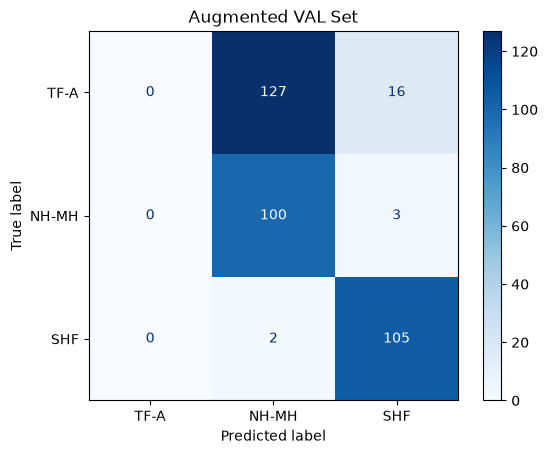

Augmented VAL Accuracy: 58.07%


In [96]:
abbrev_labels = {
    "Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in": "TF-A",
    "Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in": "NH-MH",
    "Sponge Holding Forceps Foerster Straight Serrated 9.5in": "SHF"
}

display_labels = [
    abbrev_labels[name]
    for name in label_map.keys()
]

# Evaluate on augmented VAL set
val_labels, val_preds = evaluate_model(valLoader, model, device)

cm_val = confusion_matrix(val_labels, val_preds)

disp = ConfusionMatrixDisplay(cm_val, display_labels=display_labels)
disp.plot(cmap="Blues")
plt.title("Augmented VAL Set")
plt.show()

val_acc = np.mean(np.array(val_labels) == np.array(val_preds))
print(f"Augmented VAL Accuracy: {val_acc * 100:.2f}%")


In [97]:
print(df_val_filtered["instrument"].value_counts())

instrument
Tissue Forceps Adson Straight 1x2 Teeth Mirror Finish 4.75in     143
Sponge Holding Forceps Foerster Straight Serrated 9.5in          107
Needle Holder Mayo-Hegar Straight Carb-bite Serrated Jaws 8in    103
Name: count, dtype: int64


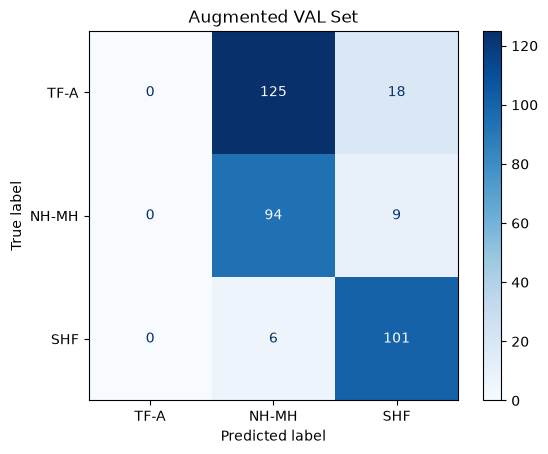

Augmented VAL Occluded Accuracy: 55.24%


In [98]:
# Evaluate on OCCLUDED augmented VAL set
val_labels, val_preds = evaluate_model(valLoaderOccluded, model, device)

cm_val = confusion_matrix(val_labels, val_preds)

disp = ConfusionMatrixDisplay(cm_val, display_labels=display_labels)
disp.plot(cmap="Blues")
plt.title("Augmented VAL Set")
plt.show()

val_acc = np.mean(np.array(val_labels) == np.array(val_preds))
print(f"Augmented VAL Occluded Accuracy: {val_acc * 100:.2f}%")